# DO APERTURE PHOTOMETRY FOR A SINGLE STAR

In [151]:
## load Libraires
import numpy as np
import os
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
import astropy.units as u
from astropy.table import Table
from scipy import interpolate
from shapely.geometry import LineString, Point
from astropy.stats import sigma_clipped_stats
from astropy.visualization import simple_norm

from photutils.aperture import aperture_photometry, CircularAnnulus, CircularAperture

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 1536                                                  NAXIS2  =                 1024                                                  EXPTIME =          40.00000000 / seconds                                        EXPOSURE=          40.00000000 / seconds                                        GAIN    =           1.50000000 / e-/ADU                                         XBINNING=                    1                                                  YBINNING=                    1                                                  FILTER  = 'Blue    '                                                            CCD-TEMP=         -10.15000000 / deg. Celsius                                   UT      = '20:07:23.006'       / begin o

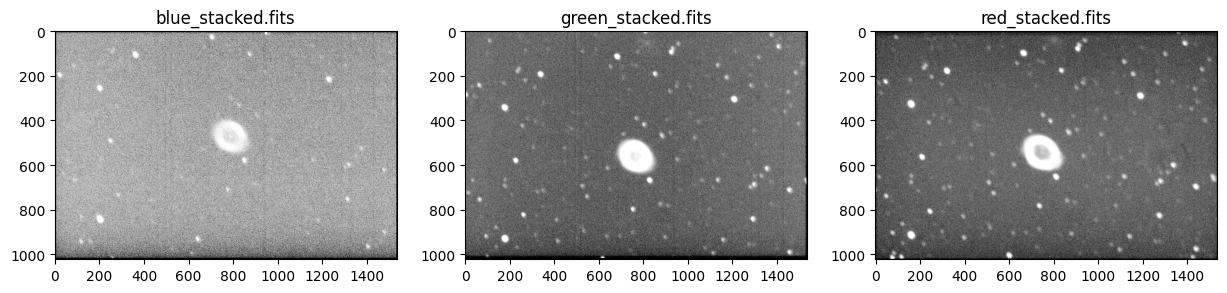

In [132]:
# Make sure filters and paths match in length
filters = ['blue', 'green', 'red']  # or adjust to match your files
paths = {}
for file in os.listdir("./m57/shifted_stacked/"):
    if file.endswith(".fits"):
        key = file.split("_")[0]
        paths[key] = (os.path.join("./m57/shifted_stacked/", file))

stacked_images = {}
headers = {}
for fil in filters:
    data, header = fits.getdata(paths[fil], header=True)
    stacked_images[fil] = data
    headers[fil] = header
    print(header)

fig, ax = plt.subplots(1, len(filters), figsize=(15, 5))
for i, fil in enumerate(filters):
    norm = simple_norm(stacked_images[fil], 'asinh', min_percent=5, max_percent=99)
    ax[i].imshow(stacked_images[fil], norm=norm, cmap='gray')
    ax[i].set_title(paths[fil].split("/")[-1])

In [133]:
## First mask sources
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
from photutils.utils import calc_total_error

Get noise image (background and Poisson error)

In [134]:
bkg_filters = {}
erimage_filters = {}

for i,image in enumerate(stacked_images.values()):
    
    sigma_clip = SigmaClip(sigma=3.0)
    threshold = detect_threshold(image, nsigma=2.0, sigma_clip=sigma_clip)
    segment_img = detect_sources(image, threshold, npixels=10)
    footprint = circular_footprint(radius=10)

    srcmask = segment_img.make_source_mask(footprint=footprint)
    #plt.imshow(srcmask)

    ## Get background image with sources masked
    
    sigma_clip = SigmaClip(sigma=3.0)
    bkg_estimator = MedianBackground()
    bkg = Background2D(image,(250,250),filter_size=(3,3),sigma_clip=sigma_clip,  ## this is the background and its noise
                    bkg_estimator=bkg_estimator)
    bkg_filters[filters[i]] = bkg
    
    erimage = calc_total_error(image-bkg.background, bkg.background_rms, 1.5)  ## this is the Poisson error added to background noise
    erimage_filters[filters[i]] = erimage

## Get central position of star with initial guess

[783.70636526 476.5498621 ]
[763.00193118 559.7239123 ]
[747.95102204 541.90690721]


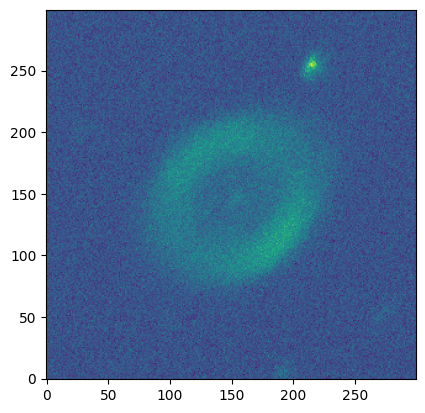

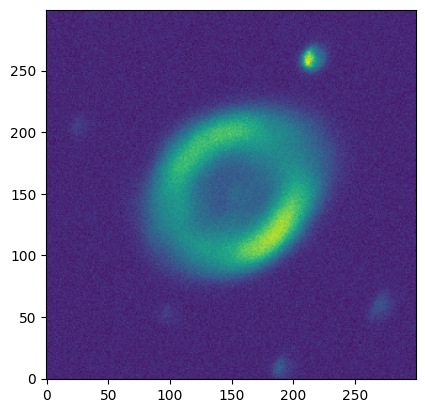

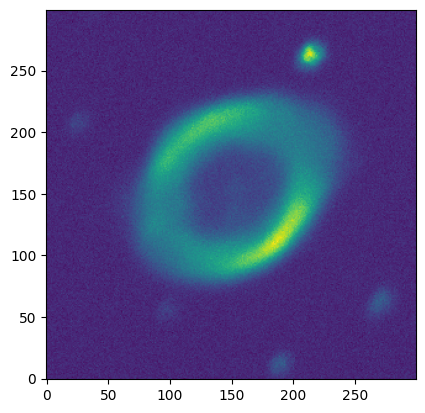

In [162]:
## Estimate position with an initial position guess of the star with centroid
pos_guess = [[784,477],
             [763,560],
             [748,542]
             ]   ## initial guess (x,y) (CHANGE TO YOUR STAR POSITION!)
from photutils.centroids import centroid_com, centroid_2dg  #load centroid libraries
positions = {}
for i, fil in enumerate(filters):
    image = stacked_images[fil]
    img = image[pos_guess[i][1]-150:pos_guess[i][1]+150, pos_guess[i][0]-150:pos_guess[i][0]+150] # select subportion of 60x60 image
    position = centroid_com(img) + np.array(pos_guess[i]) - np.array([150, 150])
    plt.figure()
    plt.imshow(img, origin='lower')
    positions[fil] = position
    print(position)


Filter blue: best SMA = 84.00, flux = 1.286e+05 ± 5.239e+02, flux per second = 3.215e+03 ± 1.310e+01, SNR = 245.48
Filter green: best SMA = 86.00, flux = 1.058e+06 ± 1.042e+03, flux per second = 2.644e+04 ± 2.605e+01, SNR = 1014.92
Filter red: best SMA = 94.00, flux = 1.503e+06 ± 1.339e+03, flux per second = 3.757e+04 ± 3.348e+01, SNR = 1122.11
{'blue': 9.56401313712453, 'green': 8.175514385864695, 'red': 7.526021907686722}


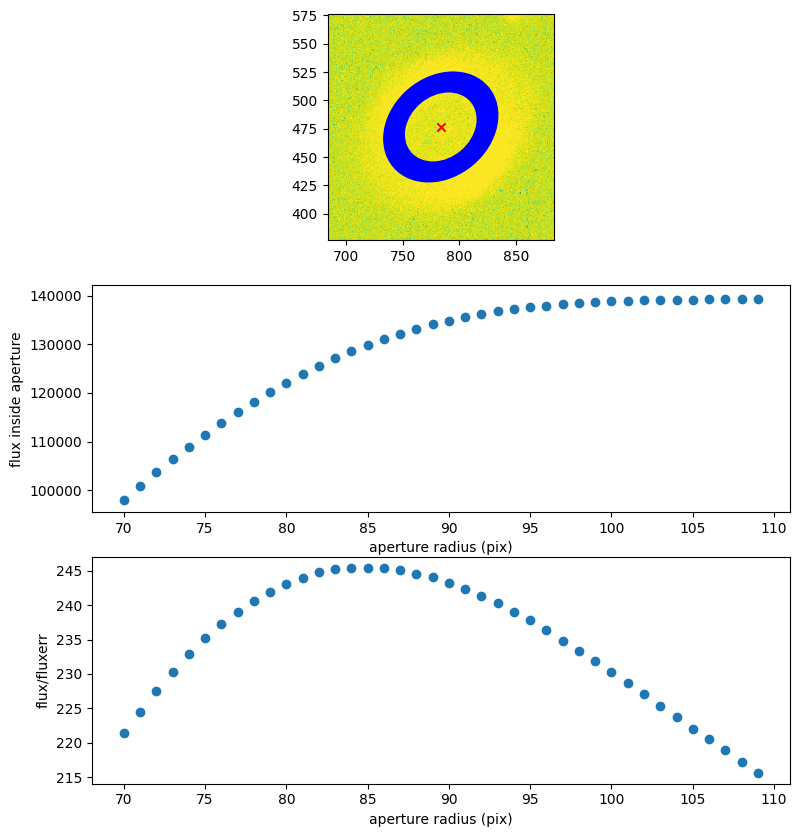

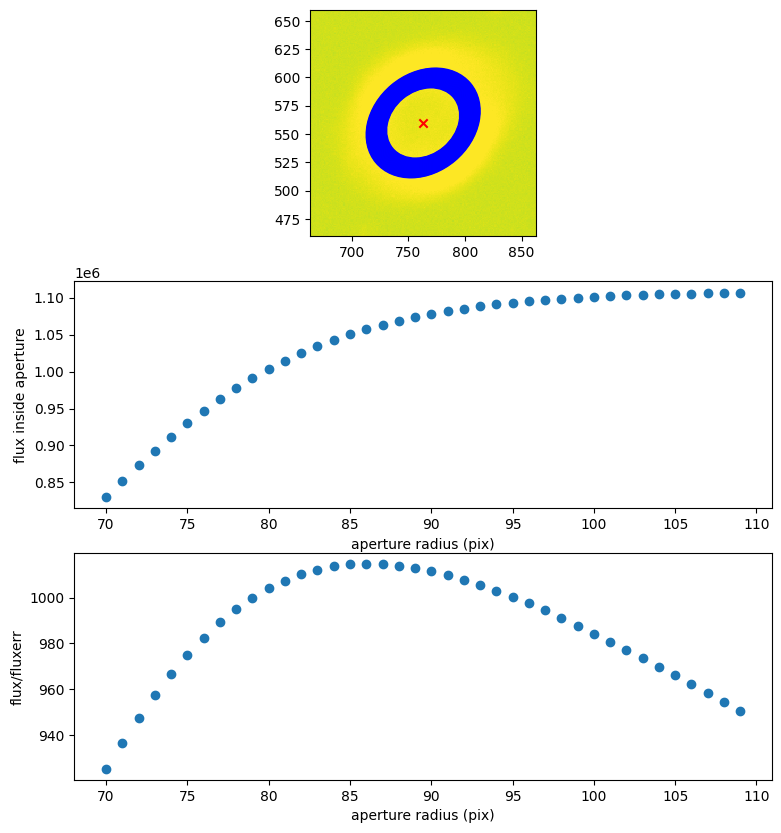

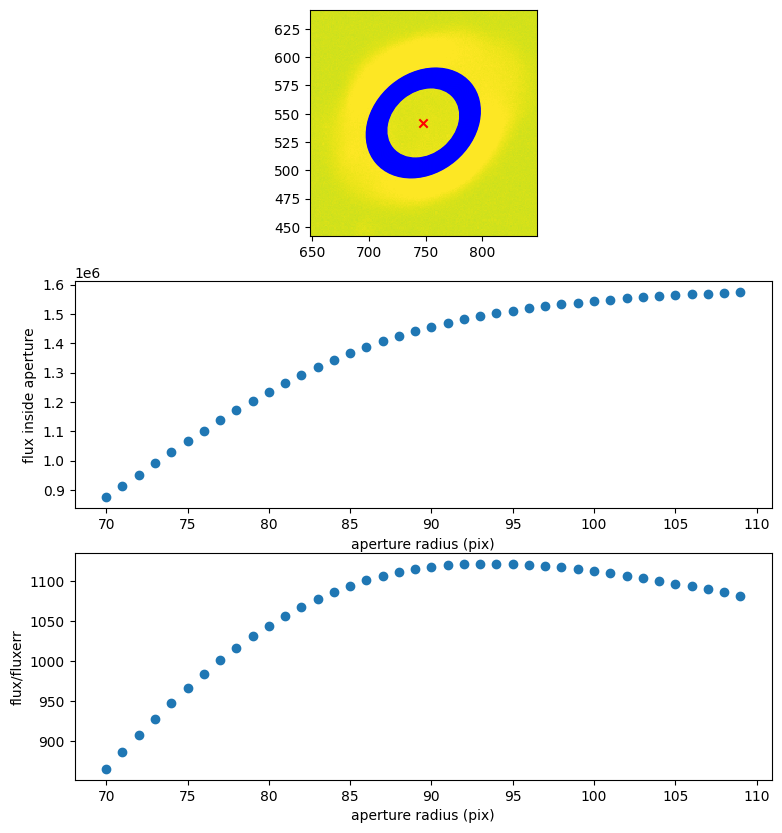

In [179]:
from photutils.aperture import EllipticalAperture
from photutils.isophote import EllipseGeometry, Ellipse

## Estimate position with an initial position guess of the star with centroid
smas = np.arange(70,110, 1)
photometry_results = {}
magnitudes = {}

# Zero points calculated from sheliak aperture photometry
zero_points = {'blue': 18.332031643285532, 'green': 19.231122335486116, 'red': 18.963123229886133}

for i, fil in enumerate(filters):
    position = positions[fil]
    image = stacked_images[fil]
    header = headers[fil]
    apertures = []
    for sma in smas:
        geometry = EllipseGeometry(x0=position[0], y0=position[1], sma=sma, eps=0.2, pa=40.0 * np.pi / 180.0) #give an initial guess for the isophote
        apertures.append(EllipticalAperture((geometry.x0, geometry.y0), geometry.sma, geometry.sma * (1 - geometry.eps), geometry.pa))    

    bkg = bkg_filters[fil]
    erimage = erimage_filters[fil]
    phot_table = aperture_photometry(image-bkg.background, apertures, error=erimage)
    y = np.asarray([phot_table['aperture_sum_'+str(i)] for i in np.arange(0, smas.size)], dtype=float)
    ery = np.asarray([phot_table['aperture_sum_err_'+str(i)] for i in np.arange(0, smas.size)], dtype=float)
    y = np.reshape(y, (len(y),))
    ery = np.reshape(ery, (len(ery),))
    photometry_results[fil] = {'phot_table': phot_table, 'y': y, 'ery': ery, 'position': position}
    # Plot curve of growth and image with apertures
    from astropy.visualization import simple_norm
    fig, ax = plt.subplots(3, figsize=(9, 10))
    norm = simple_norm(image, 'log', percent=99.)
    ax[0].imshow(image, norm=norm, aspect=1, interpolation='nearest')
    ax[0].scatter(position[0], position[1], color='red', marker='x')
    for sma in smas:
        ellipse = patches.Ellipse(position, sma, sma * 0.8, angle=40.0, edgecolor='b', fill=False)
        ax[0].add_artist(ellipse)
    ax[0].set_xlim([position[0]-100, position[0]+100])
    ax[0].set_ylim([position[1]-100, position[1]+100])
    # plot curve of growth
    ax[1].errorbar(smas, y, yerr=ery, fmt='o')
    ax[1].set_xlabel('aperture radius (pix)')
    ax[1].set_ylabel('flux inside aperture')
    # plot flux/fluxerr (S/N)
    ax[2].errorbar(smas, y/ery, fmt='o')
    ax[2].set_xlabel('aperture radius (pix)')
    ax[2].set_ylabel('flux/fluxerr')

    # compute SNR and find index of maximum
    snr = y / ery
    best_idx = np.argmax(snr)

    # record best values for this filter
    best_sma = smas[best_idx]
    best_flux = y[best_idx]
    best_flux_err = ery[best_idx]
    flux_per_second = best_flux/header['EXPTIME']
    err_per_second = best_flux_err/header['EXPTIME']

    print(f"Filter {fil}: best SMA = {best_sma:.2f}, flux = {best_flux:.3e} ± {best_flux_err:.3e}, flux per second = {flux_per_second:.3e} ± {err_per_second:.3e}, SNR = {snr[best_idx]:.2f}")

    magnitudes[fil]=float(zero_points[fil] - 2.5 * np.log10(flux_per_second))

print(magnitudes)